In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


In [2]:
df = pd.read_csv('finclaro_colombia.csv')
df.head(5)

,id_solicitante,edad,sexo,ciudad,region,estrato,nivel_educativo,estado_civil,num_dependientes,tipo_empleo,...,score_buro,num_creditos_anteriores,num_creditos_mora,dias_mora_max,monto_solicitado,plazo_meses,relacion_cuota_ingreso,tiene_codeudor,tiene_garantia,credito_aprobado
0,FC-00001,26,F,Bogotá,interior,2,posgrado,soltero,5,desempleado,...,350,0,0,0,5000000,24,0.3963,0,0,0
1,FC-00002,50,F,Bogotá,interior,4,bachillerato,soltero,0,independiente,...,620,3,2,30,1000000,24,0.0115,1,0,1
2,FC-00003,18,F,Pereira,interior,3,bachillerato,casado,1,empleado_formal,...,516,3,0,0,2000000,12,0.1068,1,1,0
3,FC-00004,45,M,Bogotá,interior,2,bachillerato,soltero,3,informal,...,434,0,0,0,3000000,36,0.0497,0,0,0
4,FC-00005,54,F,Medellín,interior,3,posgrado,union_libre,0,independiente,...,457,1,0,0,10000000,6,1.1674,1,0,0


In [3]:
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas\n")
df.info()

Dimensiones: 10,000 filas × 23 columnas

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_solicitante            10000 non-null  str    
 1   edad                      10000 non-null  int64  
 2   sexo                      10000 non-null  str    
 3   ciudad                    10000 non-null  str    
 4   region                    10000 non-null  str    
 5   estrato                   10000 non-null  int64  
 6   nivel_educativo           10000 non-null  str    
 7   estado_civil              10000 non-null  str    
 8   num_dependientes          10000 non-null  int64  
 9   tipo_empleo               10000 non-null  str    
 10  antiguedad_laboral_meses  10000 non-null  int64  
 11  ingreso_mensual           10000 non-null  int64  
 12  gastos_fijos_mensuales    10000 non-null  int64  
 13  score_buro                10000 

══════════════════════════════════════════
  DISTRIBUCIÓN DEL TARGET
══════════════════════════════════════════
  Negado    (0): 6,545  (65.5%)
  Aprobado  (1): 3,455  (34.5%)
══════════════════════════════════════════


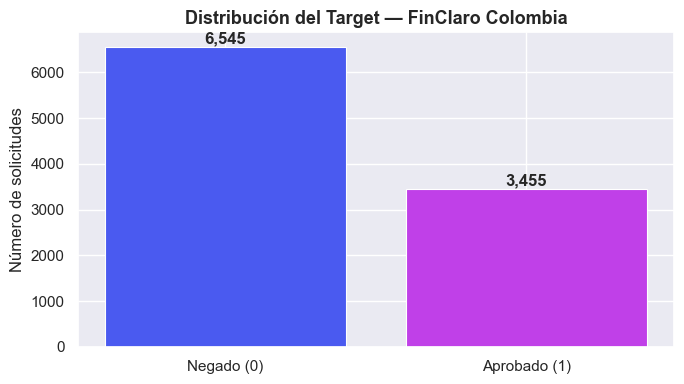

In [4]:
conteo = df['credito_aprobado'].value_counts()
pct    = df['credito_aprobado'].value_counts(normalize=True) * 100

print("═" * 42)
print("  DISTRIBUCIÓN DEL TARGET")
print("═" * 42)
print(f"  Negado    (0): {conteo[0]:>5,}  ({pct[0]:.1f}%)")
print(f"  Aprobado  (1): {conteo[1]:>5,}  ({pct[1]:.1f}%)")
print("═" * 42)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['Negado (0)', 'Aprobado (1)'],
       conteo.values, color=['#4a5af0', '#c040e8'], edgecolor='white', linewidth=0.8)
ax.set_title('Distribución del Target — FinClaro Colombia', fontsize=13, fontweight='bold')
ax.set_ylabel('Número de solicitudes')
for i, v in enumerate(conteo.values):
    ax.text(i, v + 80, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [5]:
df.describe().round(0)

,edad,estrato,num_dependientes,antiguedad_laboral_meses,ingreso_mensual,gastos_fijos_mensuales,score_buro,num_creditos_anteriores,num_creditos_mora,dias_mora_max,monto_solicitado,plazo_meses,relacion_cuota_ingreso,tiene_codeudor,tiene_garantia,credito_aprobado
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,44.0,3.0,2.0,33.0,2781888.0,1528061.0,516.0,2.0,0.0,24.0,3444100.0,24.0,0.0,0.0,0.0,0.0
std,16.0,1.0,1.0,36.0,2753049.0,1573226.0,99.0,2.0,1.0,55.0,3051370.0,14.0,0.0,0.0,0.0,0.0
min,18.0,1.0,0.0,0.0,300388.0,107823.0,350.0,0.0,0.0,0.0,500000.0,6.0,0.0,0.0,0.0,0.0
25%,31.0,2.0,0.0,7.0,1236788.0,641114.0,445.0,1.0,0.0,0.0,1000000.0,12.0,0.0,0.0,0.0,0.0
50%,44.0,3.0,1.0,22.0,1949218.0,1047452.0,510.0,2.0,0.0,0.0,2000000.0,24.0,0.0,0.0,0.0,0.0
75%,58.0,4.0,2.0,48.0,3145650.0,1764633.0,578.0,3.0,1.0,30.0,5000000.0,36.0,0.0,1.0,0.0,1.0
max,71.0,6.0,5.0,360.0,25533068.0,15203200.0,900.0,6.0,3.0,360.0,15000000.0,60.0,9.0,1.0,1.0,1.0


Tasa de aprobación por estrato socioeconómico:
──────────────────────────────────────────
  Estrato 1:   9.3%  ██
  Estrato 2:  18.4%  ████
  Estrato 3:  32.4%  ████████
  Estrato 4:  59.1%  ██████████████
  Estrato 5:  81.7%  ████████████████████
  Estrato 6:  90.4%  ██████████████████████
──────────────────────────────────────────


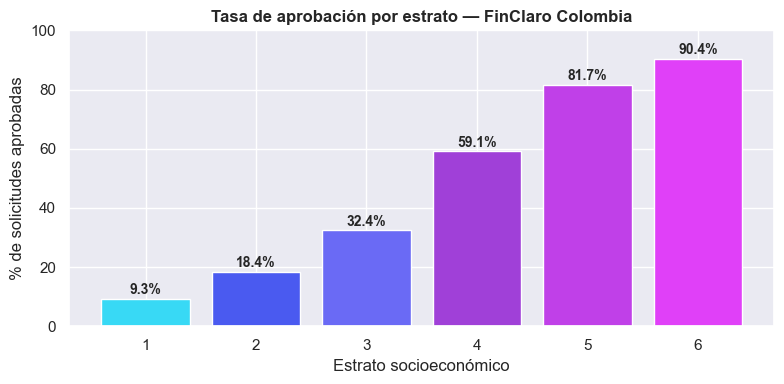

In [6]:
aprobacion_estrato = (df.groupby('estrato')['credito_aprobado']
                        .mean()
                        .mul(100)
                        .round(1))

print("Tasa de aprobación por estrato socioeconómico:")
print("─" * 42)
for estrato, tasa in aprobacion_estrato.items():
    barra = '█' * int(tasa / 4)
    print(f"  Estrato {estrato}: {tasa:5.1f}%  {barra}")
print("─" * 42)

fig, ax = plt.subplots(figsize=(8, 4))
colores = ['#38d9f5', '#4a5af0', '#6a6af5', '#a040d8', '#c040e8', '#e040f8']
ax.bar(aprobacion_estrato.index.astype(str),
       aprobacion_estrato.values, color=colores, edgecolor='white')
ax.set_title('Tasa de aprobación por estrato — FinClaro Colombia',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Estrato socioeconómico')
ax.set_ylabel('% de solicitudes aprobadas')
ax.set_ylim(0, 100)
for i, (e, v) in enumerate(aprobacion_estrato.items()):
    ax.text(i, v + 1.5, f'{v}%', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
df_model = df.copy()

# Label Encoding para binarias
df_model['sexo_enc']   = (df_model['sexo'] == 'M').astype(int)         # M=1, F=0
df_model['region_enc'] = (df_model['region'] == 'interior').astype(int) # interior=1

# One-Hot Encoding para categóricas con múltiples valores
df_model = pd.get_dummies(df_model,
                           columns=['tipo_empleo', 'nivel_educativo', 'estado_civil'],
                           drop_first=True)

print("Encoding completado.")
print(f"Columnas originales: 23  →  Columnas tras encoding: {df_model.shape[1]}")
print(f"\nNuevas columnas creadas:")
nuevas = [c for c in df_model.columns if '_' in c and c not in df.columns]
for c in nuevas:
    print(f"  · {c}")

Encoding completado.
Columnas originales: 23  →  Columnas tras encoding: 33

Nuevas columnas creadas:
  · sexo_enc
  · region_enc
  · tipo_empleo_empleado_formal
  · tipo_empleo_independiente
  · tipo_empleo_informal
  · tipo_empleo_pensionado
  · nivel_educativo_posgrado
  · nivel_educativo_primaria
  · nivel_educativo_tecnico
  · nivel_educativo_universitario
  · estado_civil_divorciado
  · estado_civil_soltero
  · estado_civil_union_libre


In [8]:
columnas_excluir = [
    'id_solicitante', 'credito_aprobado',
    'sexo', 'ciudad', 'region',
    'nivel_educativo', 'estado_civil', 'tipo_empleo'
]
  
X = df_model.drop(columns=columnas_excluir, errors='ignore')
y = df_model['credito_aprobado']
  
print(f"Variables de entrada (X): {X.shape[1]} features · {X.shape[0]:,} solicitudes")
print(f"Variable objetivo   (y): {y.shape[0]:,} valores")
print(f"\nFeatures incluidas:")

for c in X.columns:
    print(f"  · {c}")

Variables de entrada (X): 28 features · 10,000 solicitudes
Variable objetivo   (y): 10,000 valores

Features incluidas:
  · edad
  · estrato
  · num_dependientes
  · antiguedad_laboral_meses
  · ingreso_mensual
  · gastos_fijos_mensuales
  · score_buro
  · num_creditos_anteriores
  · num_creditos_mora
  · dias_mora_max
  · monto_solicitado
  · plazo_meses
  · relacion_cuota_ingreso
  · tiene_codeudor
  · tiene_garantia
  · sexo_enc
  · region_enc
  · tipo_empleo_empleado_formal
  · tipo_empleo_independiente
  · tipo_empleo_informal
  · tipo_empleo_pensionado
  · nivel_educativo_posgrado
  · nivel_educativo_primaria
  · nivel_educativo_tecnico
  · nivel_educativo_universitario
  · estado_civil_divorciado
  · estado_civil_soltero
  · estado_civil_union_libre


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("División completada:")
print(f"  Entrenamiento: {X_train.shape[0]:,} solicitudes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Prueba:        {X_test.shape[0]:,} solicitudes ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nVerificación de estratificación:")
print(f"  % aprobados en entrenamiento: {y_train.mean()*100:.1f}%")
print(f"  % aprobados en prueba:        {y_test.mean()*100:.1f}%")

División completada:
  Entrenamiento: 8,000 solicitudes (80%)
  Prueba:        2,000 solicitudes (20%)

Verificación de estratificación:
  % aprobados en entrenamiento: 34.5%
  % aprobados en prueba:        34.5%


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Escalado completado.")
print(f"\nVerificación — media de X_train_scaled (debe ser ≈ 0.000):")
medias = pd.DataFrame(X_train_scaled, columns=X.columns).mean().round(3)
print(medias.to_string())

Escalado completado.

Verificación — media de X_train_scaled (debe ser ≈ 0.000):
edad                             0.0
estrato                         -0.0
num_dependientes                -0.0
antiguedad_laboral_meses         0.0
ingreso_mensual                  0.0
gastos_fijos_mensuales          -0.0
score_buro                      -0.0
num_creditos_anteriores         -0.0
num_creditos_mora               -0.0
dias_mora_max                   -0.0
monto_solicitado                -0.0
plazo_meses                     -0.0
relacion_cuota_ingreso          -0.0
tiene_codeudor                  -0.0
tiene_garantia                   0.0
sexo_enc                         0.0
region_enc                      -0.0
tipo_empleo_empleado_formal     -0.0
tipo_empleo_independiente       -0.0
tipo_empleo_informal            -0.0
tipo_empleo_pensionado          -0.0
nivel_educativo_posgrado         0.0
nivel_educativo_primaria        -0.0
nivel_educativo_tecnico         -0.0
nivel_educativo_universitario  

In [11]:
rl = LogisticRegression(max_iter=1000, random_state=42)
rl.fit(X_train_scaled, y_train)

print("Regresión Logística entrenada")
print(f"   Features usadas:    {X_train_scaled.shape[1]}")
print(f"   Solicitudes vistas: {X_train_scaled.shape[0]:,}")

Regresión Logística entrenada
   Features usadas:    28
   Solicitudes vistas: 8,000


In [ ]:
y_pred_rl = rl.predict(X_test_scaled)

print(f"Primeras 20 predicciones: {y_pred_rl[:20]}")
print(f"Primeros  20 valores reales: {y_test.values[:20]}")
print(f"\nTotal predicciones: {len(y_pred_rl):,}")
print(f"Aprobados predichos: {y_pred_rl.sum():,} ({y_pred_rl.mean()*100:.1f}%)")

Primeras 20 predicciones: [0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 1]
Primeros  20 valores reales: [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0]

Total predicciones: 2,000
Aprobados predichos: 688 (34.4%)


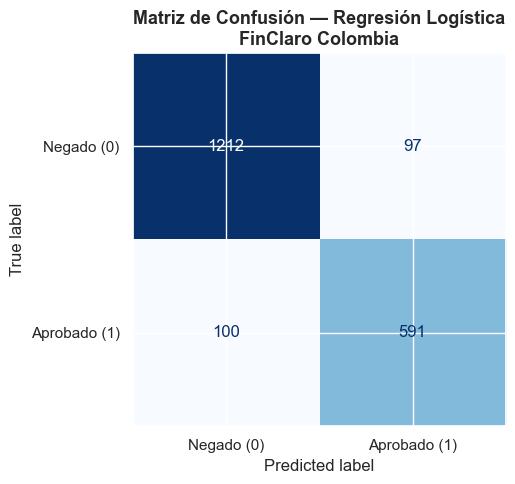


────────────────────────────────────────────────────
  Verdaderos Negativos (TN): 1,212  — negó correctamente
  Falsos Positivos     (FP):    97  — aprobó a quien incumpliría ⚠️
  Falsos Negativos     (FN):   100  — negó a quien habría pagado ❌
  Verdaderos Positivos (TP):   591  — aprobó correctamente
────────────────────────────────────────────────────
  Total solicitudes en prueba: 2,000


In [13]:
cm = confusion_matrix(y_test, y_pred_rl)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negado (0)', 'Aprobado (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Regresión Logística\nFinClaro Colombia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n{'─'*52}")
print(f"  Verdaderos Negativos (TN): {tn:>5,}  — negó correctamente")
print(f"  Falsos Positivos     (FP): {fp:>5,}  — aprobó a quien incumpliría ⚠️")
print(f"  Falsos Negativos     (FN): {fn:>5,}  — negó a quien habría pagado ❌")
print(f"  Verdaderos Positivos (TP): {tp:>5,}  — aprobó correctamente")
print(f"{'─'*52}")
print(f"  Total solicitudes en prueba: {len(y_test):,}")

In [14]:
acc_rl  = accuracy_score(y_test, y_pred_rl)
prec_rl = precision_score(y_test, y_pred_rl)
rec_rl  = recall_score(y_test, y_pred_rl)
f1_rl   = f1_score(y_test, y_pred_rl)

print("═" * 52)
print("  MÉTRICAS — Regresión Logística")
print("═" * 52)
print(f"  Accuracy  (Exactitud):     {acc_rl:.4f}  →  {acc_rl*100:.1f}%")
print(f"  Precision (Precisión):     {prec_rl:.4f}  →  {prec_rl*100:.1f}%")
print(f"  Recall    (Exhaustividad): {rec_rl:.4f}  →  {rec_rl*100:.1f}%")
print(f"  F1-Score:                  {f1_rl:.4f}  →  {f1_rl*100:.1f}%")
print("═" * 52)

print("\nReporte completo por clase:")
print(classification_report(y_test, y_pred_rl,
                             target_names=['Negado', 'Aprobado']))

════════════════════════════════════════════════════
  MÉTRICAS — Regresión Logística
════════════════════════════════════════════════════
  Accuracy  (Exactitud):     0.9015  →  90.1%
  Precision (Precisión):     0.8590  →  85.9%
  Recall    (Exhaustividad): 0.8553  →  85.5%
  F1-Score:                  0.8571  →  85.7%
════════════════════════════════════════════════════

Reporte completo por clase:
              precision    recall  f1-score   support

      Negado       0.92      0.93      0.92      1309
    Aprobado       0.86      0.86      0.86       691

    accuracy                           0.90      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.90      0.90      0.90      2000



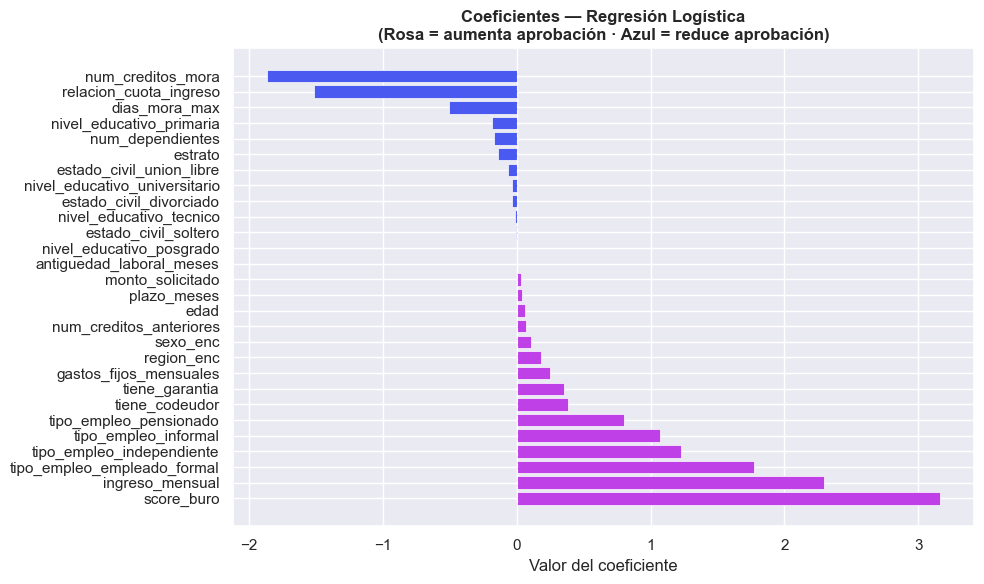

                     variable  coeficiente
                   score_buro     3.165483
              ingreso_mensual     2.293811
  tipo_empleo_empleado_formal     1.771614
    tipo_empleo_independiente     1.226662
         tipo_empleo_informal     1.073849
       tipo_empleo_pensionado     0.798402
               tiene_codeudor     0.382409
               tiene_garantia     0.353432
       gastos_fijos_mensuales     0.250035
                   region_enc     0.184462
                     sexo_enc     0.105479
      num_creditos_anteriores     0.072413
                         edad     0.059025
                  plazo_meses     0.039426
             monto_solicitado     0.031305
     antiguedad_laboral_meses     0.005388
     nivel_educativo_posgrado     0.002555
         estado_civil_soltero    -0.007530
      nivel_educativo_tecnico    -0.015391
      estado_civil_divorciado    -0.034363
nivel_educativo_universitario    -0.035245
     estado_civil_union_libre    -0.065669
           

In [15]:
coef_df = pd.DataFrame({
    'variable': X.columns,
    'coeficiente': rl.coef_[0]
}).sort_values('coeficiente', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colores_coef = ['#c040e8' if c > 0 else '#4a5af0' for c in coef_df['coeficiente']]
ax.barh(coef_df['variable'], coef_df['coeficiente'],
        color=colores_coef, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax.set_title('Coeficientes — Regresión Logística\n(Rosa = aumenta aprobación · Azul = reduce aprobación)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Valor del coeficiente')
plt.tight_layout()
plt.show()

print(coef_df.to_string(index=False))

# SEGUNDA PARTE 

In [16]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest entrenado")
print(f"   Árboles construidos: {rf.n_estimators}")
print(f"   Features usadas:     {X_train.shape[1]}")

Random Forest entrenado
   Árboles construidos: 100
   Features usadas:     28


In [17]:
y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

print("═" * 52)
print("  MÉTRICAS — Random Forest")
print("═" * 52)
print(f"  Accuracy:  {acc_rf:.4f}  →  {acc_rf*100:.1f}%")
print(f"  Precision: {prec_rf:.4f}  →  {prec_rf*100:.1f}%")
print(f"  Recall:    {rec_rf:.4f}  →  {rec_rf*100:.1f}%")
print(f"  F1-Score:  {f1_rf:.4f}  →  {f1_rf*100:.1f}%")
print("═" * 52)

════════════════════════════════════════════════════
  MÉTRICAS — Random Forest
════════════════════════════════════════════════════
  Accuracy:  0.8920  →  89.2%
  Precision: 0.8571  →  85.7%
  Recall:    0.8249  →  82.5%
  F1-Score:  0.8407  →  84.1%
════════════════════════════════════════════════════


╔══════════════════════════════════════════════════════════╗
║       COMPARACIÓN DE MODELOS — FinClaro Colombia         ║
╠══════════════════════════════════════════════════════════╣
  Modelo                  Accuracy  Precision   Recall       F1
  ──────────────────────────────────────────────────────
  Regresión Logística       0.9015     0.8590   0.8553   0.8571
  Random Forest             0.8920     0.8571   0.8249   0.8407
╚══════════════════════════════════════════════════════════╝


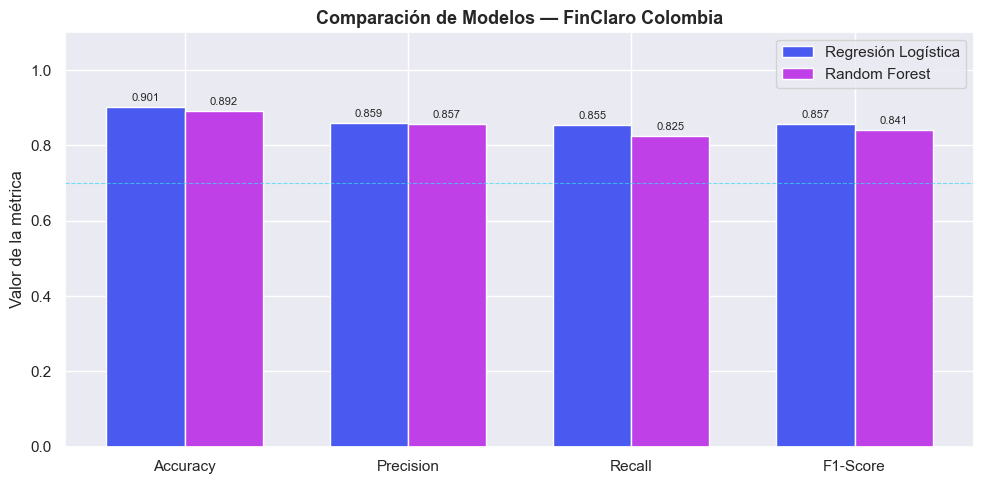

In [18]:
resultados = pd.DataFrame({
    'Modelo':     ['Regresión Logística', 'Random Forest'],
    'Accuracy':   [acc_rl,  acc_rf],
    'Precision':  [prec_rl, prec_rf],
    'Recall':     [rec_rl,  rec_rf],
    'F1-Score':   [f1_rl,   f1_rf]
})

print("╔══════════════════════════════════════════════════════════╗")
print("║       COMPARACIÓN DE MODELOS — FinClaro Colombia         ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"  {'Modelo':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("  " + "─" * 54)
for _, r in resultados.iterrows():
    print(f"  {r['Modelo']:<22} {r['Accuracy']:>9.4f} {r['Precision']:>10.4f} {r['Recall']:>8.4f} {r['F1-Score']:>8.4f}")
print("╚══════════════════════════════════════════════════════════╝")

fig, ax = plt.subplots(figsize=(10, 5))
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metricas))
w = 0.35

b1 = ax.bar(x - w/2, resultados[resultados['Modelo']=='Regresión Logística'][metricas].values[0],
            w, label='Regresión Logística', color='#4a5af0', edgecolor='white')
b2 = ax.bar(x + w/2, resultados[resultados['Modelo']=='Random Forest'][metricas].values[0],
            w, label='Random Forest', color='#c040e8', edgecolor='white')

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de Modelos — FinClaro Colombia', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(0.7, color='#38d9f5', linestyle='--', linewidth=0.8, alpha=0.7)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()


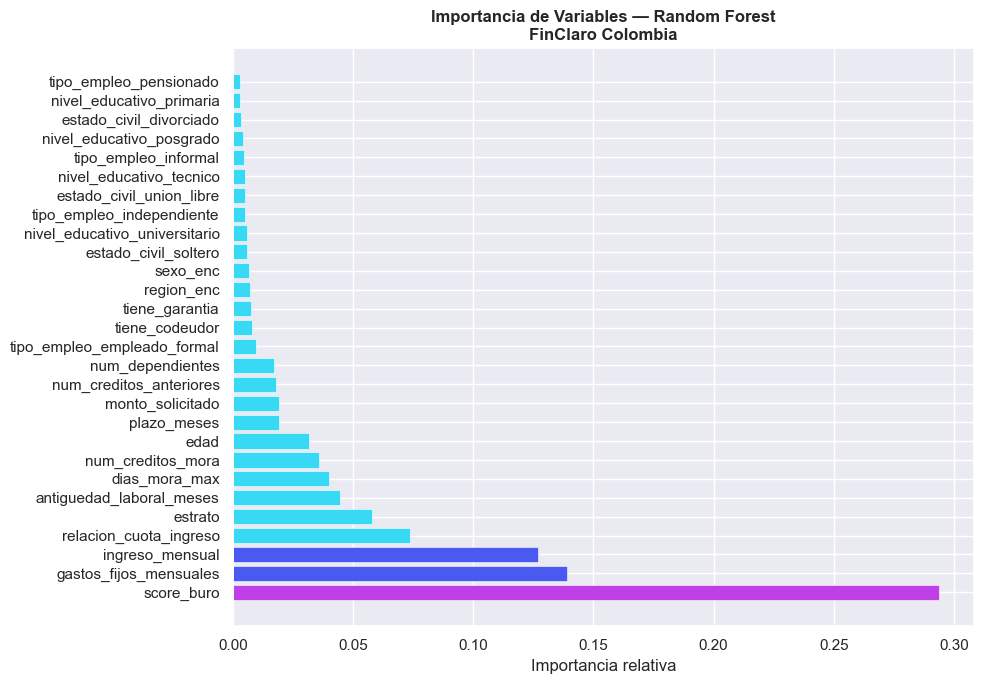

                     variable  importancia
                   score_buro     0.293698
       gastos_fijos_mensuales     0.139112
              ingreso_mensual     0.126786
       relacion_cuota_ingreso     0.073839
                      estrato     0.057673
     antiguedad_laboral_meses     0.044571
                dias_mora_max     0.039827
            num_creditos_mora     0.035935
                         edad     0.031844
                  plazo_meses     0.019291
             monto_solicitado     0.019148
      num_creditos_anteriores     0.017728
             num_dependientes     0.016878
  tipo_empleo_empleado_formal     0.009498
               tiene_codeudor     0.008033
               tiene_garantia     0.007447
                   region_enc     0.006916
                     sexo_enc     0.006664
         estado_civil_soltero     0.005994
nivel_educativo_universitario     0.005985
    tipo_empleo_independiente     0.005187
     estado_civil_union_libre     0.005067
      nivel

In [19]:
importancias = pd.DataFrame({
    'variable':    X.columns,
    'importancia': rf.feature_importances_
}).sort_values('importancia', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colores_imp = ['#c040e8' if i == 0 else '#4a5af0' if i < 3 else '#38d9f5'
               for i in range(len(importancias))]
ax.barh(importancias['variable'], importancias['importancia'],
        color=colores_imp, edgecolor='white', linewidth=0.4)
ax.set_title('Importancia de Variables — Random Forest\nFinClaro Colombia',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print(importancias.to_string(index=False))

In [20]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_recall = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='recall')
scores_f1     = cross_val_score(rf, X_train, y_train, cv=kfold, scoring='f1')

print("═" * 55)
print("  VALIDACIÓN CRUZADA — Random Forest (5 Folds)")
print("═" * 55)
print("\nRecall por fold:")
for i, s in enumerate(scores_recall, 1):
    barra = '█' * int(s * 25)
    print(f"  Fold {i}: {s:.4f}  {barra}")
print(f"\n  Media Recall:    {scores_recall.mean():.4f}  ±  {scores_recall.std():.4f}")
print(f"  Media F1-Score:  {scores_f1.mean():.4f}  ±  {scores_f1.std():.4f}")
print("═" * 55)

═══════════════════════════════════════════════════════
  VALIDACIÓN CRUZADA — Random Forest (5 Folds)
═══════════════════════════════════════════════════════

Recall por fold:
  Fold 1: 0.7844  ███████████████████
  Fold 2: 0.8282  ████████████████████
  Fold 3: 0.7975  ███████████████████
  Fold 4: 0.8029  ████████████████████
  Fold 5: 0.8047  ████████████████████

  Media Recall:    0.8035  ±  0.0142
  Media F1-Score:  0.8408  ±  0.0090
═══════════════════════════════════════════════════════


In [21]:
param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

total_combinaciones = (len(param_grid['n_estimators']) *
                       len(param_grid['max_depth']) *
                       len(param_grid['min_samples_split']))

print(f"Combinaciones a evaluar: {total_combinaciones}")
print(f"Fits totales (combinaciones × folds): {total_combinaciones * 5}")
print("Iniciando búsqueda...\n")

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)
print("\nBúsqueda completada")

Combinaciones a evaluar: 36
Fits totales (combinaciones × folds): 180
Iniciando búsqueda...

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Búsqueda completada


In [22]:
print("═" * 55)
print("  MEJORES HIPERPARÁMETROS")
print("═" * 55)
for param, valor in grid_search.best_params_.items():
    print(f"  {param:<22}: {valor}")
print(f"\n  Mejor Recall (cross-val): {grid_search.best_score_:.4f}")
print("═" * 55)

rf_opt     = grid_search.best_estimator_
y_pred_opt = rf_opt.predict(X_test)

acc_opt  = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt  = recall_score(y_test, y_pred_opt)
f1_opt   = f1_score(y_test, y_pred_opt)

print("\nRESULTADOS DEL MODELO OPTIMIZADO — test set final:")
print(f"  Accuracy:  {acc_opt:.4f}  →  {acc_opt*100:.1f}%")
print(f"  Precision: {prec_opt:.4f}  →  {prec_opt*100:.1f}%")
print(f"  Recall:    {rec_opt:.4f}  →  {rec_opt*100:.1f}%  ← métrica clave")
print(f"  F1-Score:  {f1_opt:.4f}  →  {f1_opt*100:.1f}%")

═══════════════════════════════════════════════════════
  MEJORES HIPERPARÁMETROS
═══════════════════════════════════════════════════════
  max_depth             : None
  min_samples_split     : 10
  n_estimators          : 100

  Mejor Recall (cross-val): 0.8151
═══════════════════════════════════════════════════════

RESULTADOS DEL MODELO OPTIMIZADO — test set final:
  Accuracy:  0.8855  →  88.5%
  Precision: 0.8521  →  85.2%
  Recall:    0.8090  →  80.9%  ← métrica clave
  F1-Score:  0.8300  →  83.0%
